
# AIDA-Calculus Eval Report (Finetuned Model)

This notebook summarizes the 1,000-sample AIDA-Calculus handwritten math OCR evaluation for the **Finetuned olmOCR (`olmocr-finetuned-model/`)** run.

- **Dataset scope:** `olmocr/data/aida-data/eval-10k/` (1,000 handwritten PDF equations with paired markdown ground truth)
- **Official metric:** binary pass/fail from the existing KaTeX rendering + spatial symbol matching pipeline in `olmocr/bench/tests.py`
- **Primary result:** **53.70%** pass rate (**537 / 1000**)
- **Direct comparison:** finetuned model = **53.70%**, base model = **23.70%**, delta = **+300** passed examples

The plots and error buckets in this notebook are for qualitative analysis only. The benchmark score itself comes strictly from the existing rendered pass/fail check.


In [ ]:

from __future__ import annotations

import base64
import html
import io
import json
import math
import re
import subprocess
import textwrap
from collections import Counter
from difflib import SequenceMatcher
from functools import lru_cache
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, Markdown, display
from pdf2image import convert_from_path
from PIL import Image

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 140,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "font.size": 10,
    }
)
pd.set_option("display.max_colwidth", None)

REPORT_TITLE = 'AIDA-Calculus Eval Report (Finetuned Model)'
PRIMARY_RUN_KEY = 'finetuned'
RESULTS_REL = 'inference_workspace/results/aida_eval/evaluation_results.jsonl'
SUMMARY_REL = 'inference_workspace/results/aida_eval/run_summary.txt'
OTHER_RESULTS_REL = 'inference_workspace/results/aida_eval_base/evaluation_results.jsonl'
MODEL_LABEL = 'Finetuned olmOCR (`olmocr-finetuned-model/`)'
OTHER_MODEL_LABEL = 'Base olmOCR (`allenai/olmOCR-2-7B-1025`)'
RANDOM_SAMPLE_SEED = 17
ASSUMED_SECONDS_PER_SAMPLE = 1.0
GPU_HOURLY_COST_USD = 3.40  # Editable estimate for A100 80GB PCIe runtime cost.
PAPER_COST_PER_MILLION_PAGES_USD = 176.0

EXTRACT_PATTERN = re.compile(r"\\\[(.*?)\\\]", re.S)
COMMAND_PATTERN = re.compile(r"\\[A-Za-z]+")
TOKEN_PATTERN = re.compile(r"\\[A-Za-z]+|\d+|[A-Za-z]|[^\s]")


def locate_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "olmocr").is_dir() and (candidate / "AIDA_EVAL_STATUS.md").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root from the current working directory.")


REPO_ROOT = locate_repo_root()
RESULTS_PATH = REPO_ROOT / RESULTS_REL
SUMMARY_PATH = REPO_ROOT / SUMMARY_REL
OTHER_RESULTS_PATH = REPO_ROOT / OTHER_RESULTS_REL
DATASET_DIR = REPO_ROOT / "olmocr" / "data" / "aida-data" / "eval-10k"
TOKENIZER_PATH = REPO_ROOT / "olmocr-finetuned-model"


def extract_model_latex(model_output: str) -> str:
    match = EXTRACT_PATTERN.search(model_output or "")
    return match.group(1).strip() if match else ""


def load_run(path: Path) -> pd.DataFrame:
    rows = []
    for line in path.read_text().splitlines():
        row = json.loads(line)
        row["model_output_latex"] = extract_model_latex(row.get("model_output", ""))
        rows.append(row)
    frame = pd.DataFrame(rows).sort_values("image_id").reset_index(drop=True)
    frame["outcome"] = np.where(frame["test_passed"], "Passed", "Failed")
    frame["gt_token_count"] = frame["ground_truth_latex"].map(lambda text: len(TOKEN_PATTERN.findall(text)))
    frame["pred_token_count"] = frame["model_output_latex"].map(lambda text: len(TOKEN_PATTERN.findall(text)))
    frame["char_delta"] = (frame["model_output_latex"].str.len() - frame["ground_truth_latex"].str.len()).abs()
    return frame


def parse_summary(path: Path) -> dict[str, str]:
    parsed = {}
    for line in path.read_text().splitlines():
        if ":" in line:
            key, value = line.split(":", 1)
            parsed[key.strip()] = value.strip()
    return parsed


df = load_run(RESULTS_PATH)
comparison_df = None
if OTHER_RESULTS_PATH.exists():
    comparison_df = load_run(OTHER_RESULTS_PATH)

summary_data = parse_summary(SUMMARY_PATH)
passed = int(df["test_passed"].sum())
failed = int((~df["test_passed"]).sum())
pass_rate = passed / len(df)


def normalize_latex(text: str) -> str:
    return re.sub(r"\s+", "", text or "")


def variable_tokens(text: str) -> list[str]:
    return re.findall(r"[A-Za-z]", COMMAND_PATTERN.sub(" ", text or ""))


CATEGORY_EXPLANATIONS = {
    "Missing / truncated output": "No usable equation is extracted, or the generation appears to stop before a full expression is returned.",
    "Formatting / syntax error": "The predicted LaTeX shows malformed grouping or fused function names that would be brittle or invalid to render.",
    "Symbol confusion / substitution": "The model keeps most structure but swaps a variable, digit, sign, or function token.",
    "Fraction / layout rewrite": "The model rewrites the expression into a different 2-D layout, such as stacked fractions versus inline division.",
    "Superscript / subscript attachment": "Scripts are added, dropped, or attached to the wrong symbol.",
    "Other strict-render mismatch": "The prediction is close enough to be readable, but still fails the strict rendered-symbol comparison.",
}


def categorize_failure(row: pd.Series) -> str:
    gt = row["ground_truth_latex"]
    pred = row["model_output_latex"]
    raw_output = row.get("model_output", "")

    if not pred.strip() or not EXTRACT_PATTERN.search(raw_output):
        return "Missing / truncated output"

    gt_norm = normalize_latex(gt)
    pred_norm = normalize_latex(pred)
    similarity = SequenceMatcher(None, gt_norm, pred_norm).ratio()

    if len(pred_norm) <= max(4, int(0.25 * max(len(gt_norm), 1))) and similarity < 0.45:
        return "Missing / truncated output"

    unbalanced_grouping = (
        pred.count("{") != pred.count("}")
        or pred.count("(") != pred.count(")")
        or pred.count("[") != pred.count("]")
    )
    fused_function = bool(re.search(r"\\(?:sin|cos|tan|ln|log|sec|csc|cot)(?=[A-Za-z])", pred))
    unexpected_hyperbolic = any(cmd in pred for cmd in [r"\sinh", r"\cosh", r"\tanh"]) and not any(
        cmd in gt for cmd in [r"\sinh", r"\cosh", r"\tanh"]
    )
    malformed_frac = r"\frac{}" in pred or r"\frac{" in pred and pred.count(r"\frac") > pred.count("{")
    if unbalanced_grouping or fused_function or unexpected_hyperbolic or malformed_frac:
        return "Formatting / syntax error"

    script_delta = abs(gt.count("^") - pred.count("^")) + abs(gt.count("_") - pred.count("_"))
    suspicious_extra_scripts = bool(re.search(r"[_^]\{?[0-9A-Za-z+\-]+\}?", pred)) and (
        pred.count("_") > gt.count("_") or pred.count("^") > gt.count("^")
    )
    if (script_delta >= 1 and similarity < 0.94) or (suspicious_extra_scripts and similarity < 0.90):
        return "Superscript / subscript attachment"

    gt_frac_count = gt.count(r"\frac")
    pred_frac_count = pred.count(r"\frac")
    gt_sqrt_count = gt.count(r"\sqrt")
    pred_sqrt_count = pred.count(r"\sqrt")
    gt_has_inline_slash = "/" in gt.replace(r"\frac", "")
    pred_has_inline_slash = "/" in pred.replace(r"\frac", "")
    if gt_frac_count != pred_frac_count or gt_sqrt_count != pred_sqrt_count or gt_has_inline_slash != pred_has_inline_slash:
        return "Fraction / layout rewrite"

    gt_digits = re.findall(r"\d+", gt)
    pred_digits = re.findall(r"\d+", pred)
    if variable_tokens(gt) != variable_tokens(pred) or gt_digits != pred_digits:
        return "Symbol confusion / substitution"

    return "Other strict-render mismatch"


failed_df = df.loc[~df["test_passed"]].copy()
failed_df["failure_category"] = failed_df.apply(categorize_failure, axis=1)
df = df.merge(failed_df[["image_id", "failure_category"]], on="image_id", how="left")


@lru_cache(maxsize=256)
def pdf_preview(image_id: str, dpi: int = 170) -> Image.Image | None:
    pdf_path = DATASET_DIR / f"{image_id}.pdf"
    if not pdf_path.exists():
        return None
    pages = convert_from_path(str(pdf_path), first_page=1, last_page=1, dpi=dpi, fmt="png")
    image = pages[0].convert("RGB")
    gray = np.array(image.convert("L"))
    mask = gray < 248
    if mask.any():
        ys, xs = np.where(mask)
        pad = 12
        left = max(int(xs.min()) - pad, 0)
        top = max(int(ys.min()) - pad, 0)
        right = min(int(xs.max()) + pad + 1, image.width)
        bottom = min(int(ys.max()) + pad + 1, image.height)
        image = image.crop((left, top, right, bottom))
    return image


def latex_block(text: str, width: int = 42) -> str:
    cleaned = text.strip() if text and text.strip() else "<no extracted equation>"
    return textwrap.fill(cleaned, width=width, break_long_words=False, break_on_hyphens=False)


TABLE_CSS = """
<style>
.aida-wrap {
    width: 100%;
    overflow-x: auto;
    margin: 0.5rem 0 1.25rem;
}
.aida-data {
    border-collapse: collapse;
    width: 100%;
    min-width: 820px;
}
.aida-data th,
.aida-data td {
    border: 1px solid #d7dce5;
    padding: 8px 10px;
    text-align: left;
    vertical-align: top;
    white-space: pre-wrap;
    word-break: break-word;
    overflow-wrap: anywhere;
}
.aida-data th {
    background: #eef3f8;
    font-weight: 700;
}
</style>
"""


def display_table(table: pd.DataFrame, title: str | None = None) -> None:
    display_df = table.fillna("")
    header_html = "".join(f"<th>{html.escape(str(col))}</th>" for col in display_df.columns)
    rows_html = []
    for _, row in display_df.iterrows():
        cells = "".join(f"<td>{html.escape(str(value))}</td>" for value in row.tolist())
        rows_html.append(f"<tr>{cells}</tr>")
    title_html = f"<h3>{html.escape(title)}</h3>" if title else ""
    html_out = (
        TABLE_CSS
        + title_html
        + '<div class="aida-wrap"><table class="aida-data"><thead><tr>'
        + header_html
        + '</tr></thead><tbody>'
        + ''.join(rows_html)
        + '</tbody></table></div>'
    )
    display(HTML(html_out))


def detect_gpu_names() -> str:
    try:
        output = subprocess.check_output(
            ["nvidia-smi", "--query-gpu=name", "--format=csv,noheader"], text=True
        ).splitlines()
        cleaned = sorted({name.strip() for name in output if name.strip()})
        return ", ".join(cleaned) if cleaned else "Unavailable"
    except Exception:
        return "Unavailable"


def load_tokenizer():
    try:
        from transformers import AutoTokenizer
        return AutoTokenizer.from_pretrained(str(TOKENIZER_PATH), trust_remote_code=True)
    except Exception:
        return None


TOKENIZER = load_tokenizer()
TOKEN_COUNT_METHOD = "Qwen tokenizer" if TOKENIZER is not None else "regex fallback"


def generation_token_count(text: str) -> int:
    if TOKENIZER is not None:
        return len(TOKENIZER.encode(text or "", add_special_tokens=False))
    return len(TOKEN_PATTERN.findall(text or ""))


df["generation_tokens"] = df["model_output"].map(generation_token_count)



def image_to_base64(image: Image.Image | None, max_size: tuple[int, int] = (420, 240)) -> str | None:
    if image is None:
        return None
    preview = image.copy()
    preview.thumbnail(max_size)
    buffer = io.BytesIO()
    preview.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("ascii")


def render_random_examples(frame: pd.DataFrame, title: str) -> None:
    rows_html = []
    for _, row in frame.iterrows():
        image_b64 = image_to_base64(pdf_preview(str(row["image_id"])))
        image_html = (
            f'<img class="aida-thumb" src="data:image/png;base64,{image_b64}" alt="{row["image_id"]} preview" />'
            if image_b64
            else "<em>Preview unavailable</em>"
        )
        failure_bucket = row.get("failure_category")
        if pd.isna(failure_bucket):
            failure_bucket = ""
        gt_text = row["ground_truth_latex"] or "<no ground truth>"
        pred_text = row["model_output_latex"] or "<no extracted equation>"
        rows_html.append(
            f"""
            <tr>
                <td><strong>{html.escape(str(row['image_id']))}</strong></td>
                <td>{html.escape(str(row['outcome']))}</td>
                <td>{image_html}</td>
                <td><div class="aida-code-block">{html.escape(gt_text)}</div></td>
                <td><div class="aida-code-block">{html.escape(pred_text)}</div></td>
                <td>{html.escape(str(failure_bucket))}</td>
            </tr>
            """
        )

    table_html = (
        TABLE_CSS
        + """
        <style>
        .aida-qualitative .aida-thumb {
            max-width: 380px;
            max-height: 200px;
            display: block;
            margin: 0 auto;
            background: white;
            border: 1px solid #d7dce5;
        }
        .aida-qualitative .aida-code-block {
            white-space: pre-wrap;
            word-break: break-word;
            overflow-wrap: anywhere;
            font-family: ui-monospace, SFMono-Regular, Menlo, Consolas, monospace;
            font-size: 12px;
            line-height: 1.45;
        }
        .aida-qualitative .aida-col-id {
            min-width: 90px;
        }
        .aida-qualitative .aida-col-outcome {
            min-width: 110px;
        }
        .aida-qualitative .aida-col-image {
            min-width: 400px;
        }
        .aida-qualitative .aida-col-latex {
            min-width: 420px;
        }
        .aida-qualitative .aida-col-failure {
            min-width: 240px;
        }
        </style>
        """
        + f"<h3>{html.escape(title)}</h3>"
        + """
        <div class="aida-wrap">
          <table class="aida-data aida-qualitative">
            <thead>
              <tr>
                <th class="aida-col-id">Sample</th>
                <th class="aida-col-outcome">Outcome</th>
                <th class="aida-col-image">Handwritten PDF crop</th>
                <th class="aida-col-latex">Ground-truth LaTeX</th>
                <th class="aida-col-latex">Model output</th>
                <th class="aida-col-failure">Failure bucket</th>
              </tr>
            </thead>
            <tbody>
        """
        + "".join(rows_html)
        + """
            </tbody>
          </table>
        </div>
        """
    )
    display(HTML(table_html))


print(f"Loaded {len(df)} rows from {RESULTS_PATH.relative_to(REPO_ROOT)}")
print(f"Primary model: {MODEL_LABEL}")



## Quantitative Results

The official score is a strict binary pass/fail result from the existing olmOCR benchmark code. A sample passes only when the generated equation, after normalization and extraction, produces a rendered symbol layout that matches the reference equation closely enough under the KaTeX-based spatial comparison.


In [2]:

quant_table = pd.DataFrame(
    [
        ("Dataset", "AIDA-Calculus eval-10k"),
        ("Scope", "1,000 handwritten equation PDFs with paired markdown ground truth"),
        ("Pass criterion", "Rendered math symbols must match the reference layout under KaTeX-based spatial comparison"),
        ("Normalization", "Aggressive string cleanup before scoring; final metric remains binary pass/fail"),
        ("Primary model", MODEL_LABEL),
        ("Passed", f"{passed}"),
        ("Failed", f"{failed}"),
        ("Pass rate", f"{pass_rate:.2%} ({passed}/{len(df)})"),
    ],
    columns=["Metric", "Value"],
)
display_table(quant_table, "Primary run summary")


Metric,Value
Dataset,AIDA-Calculus eval-10k
Scope,"1,000 handwritten equation PDFs with paired markdown ground truth"
Pass criterion,Rendered math symbols must match the reference layout under KaTeX-based spatial comparison
Normalization,Aggressive string cleanup before scoring; final metric remains binary pass/fail
Primary model,Finetuned olmOCR (`olmocr-finetuned-model/`)
Passed,537
Failed,463
Pass rate,53.70% (537/1000)


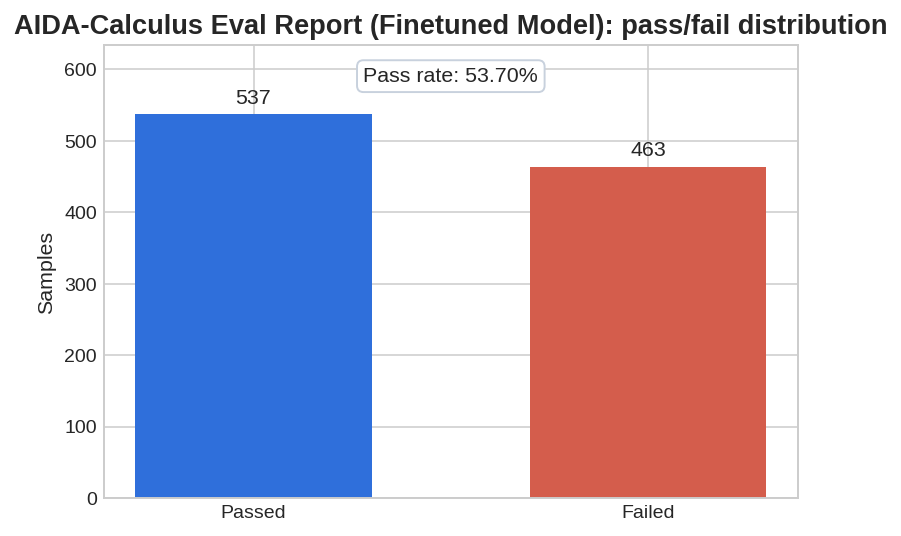

In [3]:

counts = df["outcome"].value_counts().reindex(["Passed", "Failed"])
colors = ["#2f6fdb", "#d45d4c"]
fig, ax = plt.subplots(figsize=(6.4, 4.2))
bars = ax.bar(counts.index, counts.values, color=colors, width=0.6)
ax.set_title(f"{REPORT_TITLE}: pass/fail distribution")
ax.set_ylabel("Samples")
ax.set_ylim(0, max(counts.values) * 1.18)
for bar, value in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 10, str(int(value)), ha="center", va="bottom", fontsize=11)
ax.text(
    0.5,
    0.92,
    f"Pass rate: {pass_rate:.2%}",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    bbox={"boxstyle": "round,pad=0.3", "facecolor": "white", "edgecolor": "#c8d1dd"},
)
plt.show()



## Finetuned vs Base Comparison

This section keeps the base-model baseline visible so the AIDA result can be interpreted as an actual gain from finetuning rather than as a standalone percentage.


Comparison metric,Value,Interpretation
Base olmOCR,237/1000,23.70%
Finetuned olmOCR,537/1000,53.70%
Absolute gain from finetuning,+300 passed,+30.00%
Finetuned-only wins,324,Samples recovered only by finetuning
Base-only wins,24,Samples passed only by the base model
Shared passes / shared fails,213 / 439,"Agreement on the same 1,000 examples"


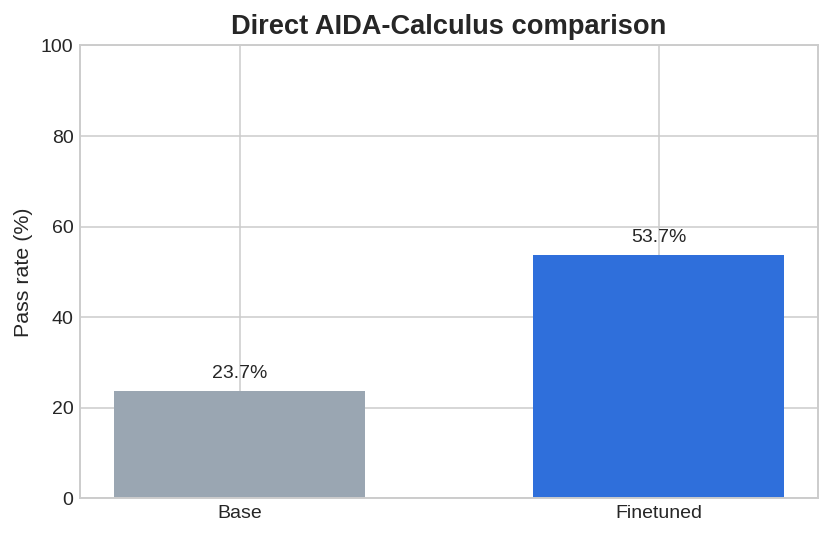

In [4]:

comparison_summary = None
if comparison_df is not None:
    base_like = df if PRIMARY_RUN_KEY == "base" else comparison_df
    ft_like = df if PRIMARY_RUN_KEY == "finetuned" else comparison_df

    base_passed = int(base_like["test_passed"].sum())
    ft_passed = int(ft_like["test_passed"].sum())
    total = len(df)
    joined = base_like[["image_id", "test_passed"]].merge(
        ft_like[["image_id", "test_passed"]],
        on="image_id",
        suffixes=("_base", "_finetuned"),
    )
    base_only = int(((joined["test_passed_base"]) & (~joined["test_passed_finetuned"])) .sum())
    ft_only = int(((joined["test_passed_finetuned"]) & (~joined["test_passed_base"])) .sum())
    both_pass = int(((joined["test_passed_base"]) & (joined["test_passed_finetuned"])) .sum())
    both_fail = int((~joined["test_passed_base"] & ~joined["test_passed_finetuned"]).sum())

    comparison_summary = pd.DataFrame(
        [
            ("Base olmOCR", f"{base_passed}/{total}", f"{base_passed / total:.2%}"),
            ("Finetuned olmOCR", f"{ft_passed}/{total}", f"{ft_passed / total:.2%}"),
            ("Absolute gain from finetuning", f"+{ft_passed - base_passed} passed", f"+{(ft_passed - base_passed) / total:.2%}"),
            ("Finetuned-only wins", f"{ft_only}", "Samples recovered only by finetuning"),
            ("Base-only wins", f"{base_only}", "Samples passed only by the base model"),
            ("Shared passes / shared fails", f"{both_pass} / {both_fail}", "Agreement on the same 1,000 examples"),
        ],
        columns=["Comparison metric", "Value", "Interpretation"],
    )
    display_table(comparison_summary, "Base vs finetuned summary")

    fig, ax = plt.subplots(figsize=(6.8, 4.2))
    labels = ["Base", "Finetuned"]
    rates = [base_passed / total * 100, ft_passed / total * 100]
    bars = ax.bar(labels, rates, color=["#9aa6b2", "#2f6fdb"], width=0.6)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Pass rate (%)")
    ax.set_title("Direct AIDA-Calculus comparison")
    for bar, value in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width() / 2, value + 2, f"{value:.1f}%", ha="center", va="bottom")
    plt.show()



## Qualitative Side-by-Side Visuals

The next cell recreates the kind of manual side-by-side inspection described in the olmOCR paper workflow. It randomly samples **3 passed** and **3 failed** examples from this run and renders a composite view for each example:

- handwritten PDF crop
- ground-truth LaTeX
- actual model output

A fixed random seed is used so the notebook remains reproducible.


Sample,Outcome,Handwritten PDF crop,Ground-truth LaTeX,Model output,Failure bucket
000320,Passed,,\lim_{s\to\frac{\pi}{4}}\cos^{4}{s}+\tan^{4}{s},\lim_{s\to\frac{\pi}{4}}\cos^{4}s+\tan^{4}s,
000980,Passed,,\lim_{g\to5^{+}}\frac{-2\sin{g}\sec^{6}{g}}{\left(2+2g\sin{g}\right)\cot^{3}{g}},\lim_{g\to5^{+}}\frac{-2\sin{g}\sec^{6}{g}}{\left(2+2g\sin{g}\right)\cot^{3}{g}},
000628,Passed,,\frac{\lim_{s\to6}7\left(\frac{2}{9}\left(4s+\left(-4s^{6}\right)^{\frac{2}{3}}\right)\left(2+-5s^{3}\right)+-8\frac{9}{8}s^{\frac{6}{4}}\right)}{\lim_{s\to5}2+-4\frac{3}{9}s^{\frac{9}{8}}},\frac{\lim_{s\to6}7\left(\frac{2}{9}\left(4s+\left(-4s^{6}\right)^{\frac{2}{3}}\right)\left(2+-5s^{3}\right)+-8\frac{9}{8}s^{\frac{6}{4}}\right)}{\lim_{s\to5}2+-4\frac{3}{9}s^{\frac{9}{8}}},

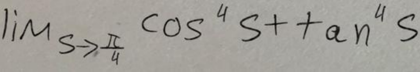
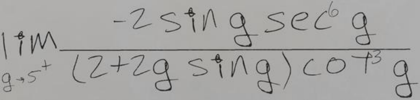
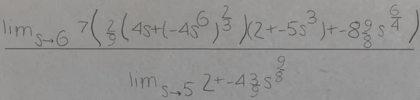

Sample,Outcome,Handwritten PDF crop,Ground-truth LaTeX,Model output,Failure bucket
000460,Failed,,\lim_{r\to\frac{\pi}{9}}\tan^{9}{r}+\tan^{9}{r},\lim_{n\to\frac{\pi}{9}}\tan^{9}{n}+\tan^{9}{n},Symbol confusion / substitution
000600,Failed,,\lim_{v\to3}v+1,\lim_{v\to2}v+1,Symbol confusion / substitution
000750,Failed,,\lim_{n\to2^{+}}\frac{-\cos{n}\sec^{3}{n}}{\sec^{5}{n}+\left(7n\sin+5\right)\tan^{1}{n}},\lim_{n\to2^{+}}\frac{-\cos{n}\sec^{3}{n}}{\sec^{5}{n}+\left(7n\sin{}+5\right)\tan^{1}{n}},Other strict-render mismatch

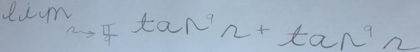
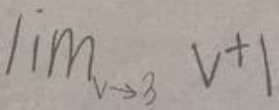
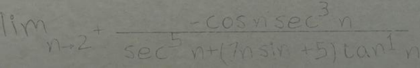

In [5]:

sampled_passed = df.loc[df["test_passed"]].sample(n=min(3, passed), random_state=RANDOM_SAMPLE_SEED)
sampled_failed = df.loc[~df["test_passed"]].sample(n=min(3, failed), random_state=RANDOM_SAMPLE_SEED + 1)
render_random_examples(sampled_passed, "Random passed examples")
render_random_examples(sampled_failed, "Random failed examples")



## Failure Categorization

The failed samples are bucketed into analysis-oriented categories that are easier to present on slides than a flat failure count. These buckets are heuristic and exist only for diagnosis; the benchmark score itself is still the binary KaTeX-based pass/fail result.


In [6]:

category_counts = failed_df["failure_category"].value_counts().rename_axis("Error category").reset_index(name="Count")
category_counts["Share of failures (%)"] = (category_counts["Count"] / max(failed, 1) * 100).round(2)
category_counts["Interpretation"] = category_counts["Error category"].map(CATEGORY_EXPLANATIONS)
display_table(category_counts, "Failure buckets")


Error category,Count,Share of failures (%),Interpretation
Symbol confusion / substitution,241,52.05,"The model keeps most structure but swaps a variable, digit, sign, or function token."
Superscript / subscript attachment,90,19.44,"Scripts are added, dropped, or attached to the wrong symbol."
Other strict-render mismatch,73,15.77,"The prediction is close enough to be readable, but still fails the strict rendered-symbol comparison."
Fraction / layout rewrite,50,10.8,"The model rewrites the expression into a different 2-D layout, such as stacked fractions versus inline division."
Formatting / syntax error,5,1.08,The predicted LaTeX shows malformed grouping or fused function names that would be brittle or invalid to render.
Missing / truncated output,4,0.86,"No usable equation is extracted, or the generation appears to stop before a full expression is returned."


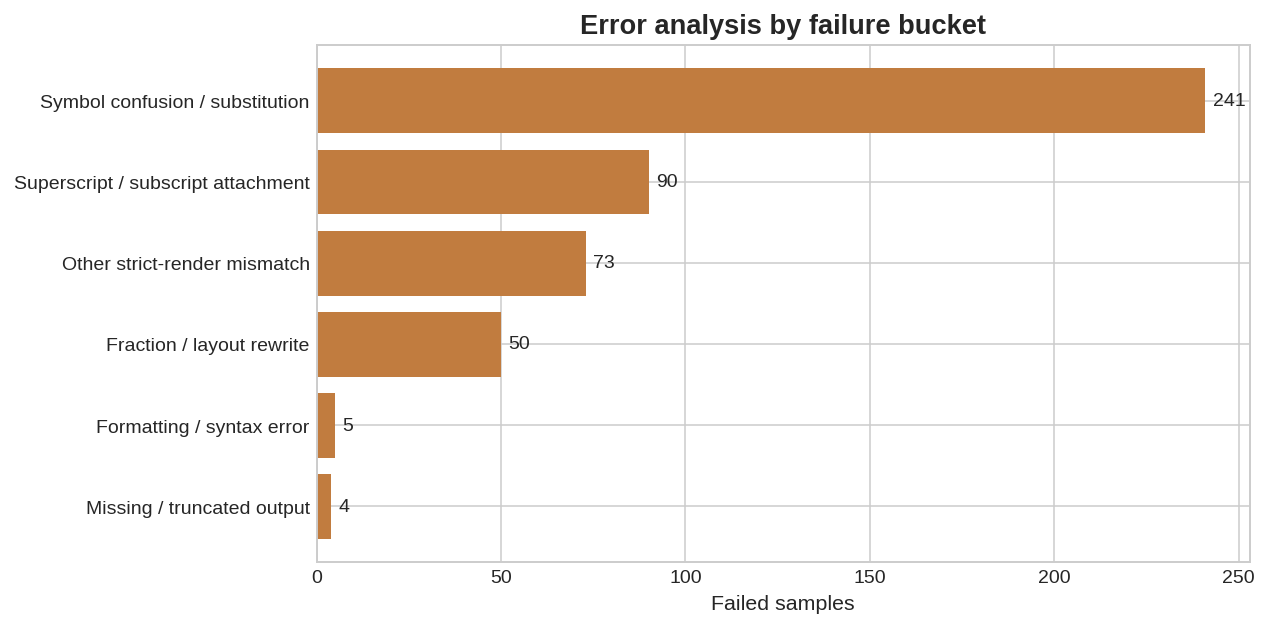

In [7]:

plot_counts = category_counts.sort_values("Count", ascending=True)
fig, ax = plt.subplots(figsize=(8.6, 4.8))
ax.barh(plot_counts["Error category"], plot_counts["Count"], color="#c17c3f")
ax.set_title("Error analysis by failure bucket")
ax.set_xlabel("Failed samples")
for y, value in enumerate(plot_counts["Count"]):
    ax.text(value + 2, y, str(int(value)), va="center", fontsize=10)
plt.show()



## Throughput and Efficiency

Exact wall-clock duration was not logged by `eval_aida.py`, so this section uses the provided rule of thumb of **about 1 second per sample** for slide-ready efficiency estimates. Update `ASSUMED_SECONDS_PER_SAMPLE` or `GPU_HOURLY_COST_USD` in the setup cell if you want to reflect a different runtime or provider cost.


In [8]:

total_samples = len(df)
total_seconds = total_samples * ASSUMED_SECONDS_PER_SAMPLE
total_minutes = total_seconds / 60.0
total_hours = total_seconds / 3600.0
total_generation_tokens = int(df["generation_tokens"].sum())
avg_generation_tokens = float(df["generation_tokens"].mean())
tokens_per_second = total_generation_tokens / total_seconds if total_seconds else float("nan")
pages_per_second = total_samples / total_seconds if total_seconds else float("nan")
estimated_batch_cost = total_hours * GPU_HOURLY_COST_USD
paper_equivalent_cost = PAPER_COST_PER_MILLION_PAGES_USD * total_samples / 1_000_000

efficiency_table = pd.DataFrame(
    [
        ("Samples", f"{total_samples}"),
        ("Timing assumption", f"{ASSUMED_SECONDS_PER_SAMPLE:.2f} sec / sample"),
        ("Estimated total inference time", f"{total_seconds:.0f} sec (~{total_minutes:.1f} min)"),
        ("Estimated throughput", f"{pages_per_second:.2f} pages / sec"),
        ("Generated token count", f"{total_generation_tokens} ({TOKEN_COUNT_METHOD})"),
        ("Average generated tokens / sample", f"{avg_generation_tokens:.2f}"),
        ("Average generation rate", f"{tokens_per_second:.2f} tokens / sec"),
        ("Detected hardware", detect_gpu_names()),
        ("Assumed GPU hourly cost", f"${GPU_HOURLY_COST_USD:.2f} / hour"),
        ("Estimated cost for this 1K batch", f"${estimated_batch_cost:.3f}"),
        ("Paper-equivalent L40S cost for 1K pages", f"${paper_equivalent_cost:.3f} using $176 / million pages"),
    ],
    columns=["Metric", "Value"],
)
display_table(efficiency_table, "Efficiency snapshot")


Metric,Value
Samples,1000
Timing assumption,1.00 sec / sample
Estimated total inference time,1000 sec (~16.7 min)
Estimated throughput,1.00 pages / sec
Generated token count,66009 (Qwen tokenizer)
Average generated tokens / sample,66.01
Average generation rate,66.01 tokens / sec
Detected hardware,NVIDIA A100 80GB PCIe
Assumed GPU hourly cost,$3.40 / hour
Estimated cost for this 1K batch,$0.944



## Why This Score Trails The Paper's 75.5% Benchmark Result

- The paper's reported `75.5 ± 1.0%` pass rate is on **OLMOCR-BENCH**, a broader benchmark that includes typed arXiv-style math and document pages, not only handwritten calculus.
- AIDA-Calculus is a **handwritten** dataset with high stroke variability, messy scripts, and symbol ambiguity that is much harsher than rendered fonts.
- This run uses the same strict binary KaTeX spatial matching rule, so small symbol swaps or layout rewrites still fail the whole sample.
- The comparison is also not perfectly apples-to-apples because the paper result references the **anchored** olmOCR model, while this AIDA workflow evaluates a separate finetuned/base setup on a different task distribution.
- In practice, the base-vs-finetuned delta on AIDA is the more meaningful local comparison for this project than the absolute gap to OLMOCR-BENCH.


In [9]:

takeaway_rows = [
    ("Primary pass rate", f"{pass_rate:.2%}"),
    ("Failure count", f"{failed}"),
    ("Top failure bucket", category_counts.iloc[0]["Error category"] if not category_counts.empty else "n/a"),
    ("Average GT token count (passed)", f"{df.loc[df['outcome'] == 'Passed', 'gt_token_count'].mean():.2f}"),
    ("Average GT token count (failed)", f"{df.loc[df['outcome'] == 'Failed', 'gt_token_count'].mean():.2f}"),
]
display_table(pd.DataFrame(takeaway_rows, columns=["Takeaway", "Value"]), "Quick takeaways")


Takeaway,Value
Primary pass rate,53.70%
Failure count,463
Top failure bucket,Symbol confusion / substitution
Average GT token count (passed),33.92
Average GT token count (failed),37.79
